In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt

In [5]:
def load_coerece(experiment):
    folder = f"results/wigner_{experiment}"
    t = np.load(os.path.join(folder, "t.npy"))

    if experiment in ['cos1', 'cos2','cos3',"cos5",'linear1', 'linear2', 'linear3', 'linear4', 'linear5', 'linear6',
                      'exp1', 'exp2', 'exp3', 'exp4', 'exp5', 'exp6']:
        list = np.load(os.path.join(folder, "w_list.npy"))
    elif experiment in ['gauss1', 'gauss2', 'gauss4','gauss5']:
        list = np.load(os.path.join(folder, "ep_list.npy")) 
    elif experiment in ['gauss3','gauss6']:
        list = np.load(os.path.join(folder, "T_list.npy"))
    elif experiment in ['cos4']:
        list = np.load(os.path.join(folder, 'phi_list.npy'))

    var_aberto = np.load(os.path.join(folder, "var_aberto.npy"), allow_pickle=True)
    const_aberto = np.load(os.path.join(folder, "const_aberto.npy"), allow_pickle=True)

    C_wt = np.vstack([np.asarray(row, dtype=np.complex128).ravel() for row in var_aberto])
    C_wt = np.real(C_wt)  # coherence should be real; keep real part safely

    const_aberto = np.asarray(const_aberto, dtype=np.complex128).ravel()
    const_aberto = np.real(const_aberto)

    # Difference: var_aberto(w,t) - const_aberto(t)
    D_wt = C_wt - const_aberto[None, :]
    return list, C_wt, D_wt, const_aberto, t


# --- MINIMAL ADD: centers -> edges (for non-uniform spacing) ---
def _edges_from_centers(x):
    x = np.asarray(x)
    dx = np.diff(x)
    edges = np.empty(x.size + 1, dtype=x.dtype)
    edges[1:-1] = x[:-1] + dx / 2
    edges[0] = x[0] - dx[0] / 2
    edges[-1] = x[-1] + dx[-1] / 2
    return edges


def plot_coherence_and_difference(
    t,
    list,
    C_wt,
    D_wt,
    cmap_var=None,
    cmap_diff=None,
    experiment="linear1"
):

    # --- MINIMAL ADD: edges for non-uniform t/list ---
    t_edges = _edges_from_centers(t)
    list_edges = _edges_from_centers(list)

    # ==========================
    # Plot 1: Coerência
    # ==========================
    plt.figure()
    plt.pcolormesh(
        t_edges, list_edges, C_wt,
        shading="auto",
        cmap=cmap_var
    )
    plt.xlabel("$t$",fontsize=20)

    if experiment in ['cos1', 'cos2', 'cos3', 'linear1', 'linear2', 'linear3', 'linear4', 'linear5', 'linear6',
                      'exp1', 'exp2', 'exp3', 'exp4', 'exp5', 'exp6']:
        plt.ylabel(r"$\omega$",fontsize=20)
    elif experiment in ['gauss1', 'gauss2', 'gauss4', 'gauss5']:
        plt.ylabel(r"$\zeta$",fontsize=20)
    elif experiment in ['gauss3','gauss6']:
        plt.ylabel(r"$T$",fontsize=20)
    elif experiment in ['cos4']:
        plt.ylabel(r'$\phi$', fontsize=20)

    plt.colorbar(label=r"$C(\rho^{(Q)})$")
    plt.tight_layout()
    plt.show()

    # ==========================
    # Plot 2: Diferença
    # ==========================
    plt.figure()
    plt.pcolormesh(
        t_edges, list_edges, D_wt,
        shading="auto",
        cmap=cmap_diff
    )
    plt.xlabel("t",fontsize=20)

    if experiment in ['linear1', 'linear2', 'linear3', 'linear4', 'linear5', 'linear6',
                      'exp1', 'exp2', 'exp3', 'exp4', 'exp5', 'exp6']:
        plt.ylabel(r"$\omega$", fontsize=20)
    elif experiment in ['gauss1', 'gauss2', 'gauss4', 'gauss5']:
        plt.ylabel(r"$\zeta$", fontsize=20)
    elif experiment in ['gauss3','gauss6']:
        plt.ylabel(r"$T$", fontsize=20)
    elif experiment in ['cos4']:
        plt.ylabel(r'$\phi$', fontsize=20)

    plt.colorbar(label=r"$\Delta C(\rho^{(Q)})$")
    plt.tight_layout()
    plt.show()


def plot_selected_coherences(
    t,
    const,
    C_wt,
    list,
    indices,
    scale_factor=1e-3,
    yscale="log"
):
    plt.figure()

    # curva constante
    plt.plot(t, const, label=r"$g_0$")

    # curvas selecionadas
    for i in indices:
        d_val = list[i]**2 / scale_factor
        label = rf"$g_t$ with $d={d_val:.5g}$"
        plt.plot(t, C_wt[i], label=label)

    plt.yscale(yscale)
    plt.xlabel("$t$", fontsize=20)
    plt.ylabel(r"$C(\rho^{Q})$")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# 0. Parâmetros gerais



# 3. Gaussiana
Vamos considerar a modulação do tipo gaussiana,

\begin{equation}
    g(t) = g_0 \exp\left[\frac{\sigma(t-T)^2}{\zeta^2}\right],
\end{equation}
mas modificando os tais parâmetros para compreender diferentes cenários físicos.

## 3.1 Pico no meio e variando a espessura do pico
Aqui, vamos verifical tal comportamento fazendo $\sigma=-1$ e $6 < \zeta < 10$.

### 3.1.1 - $T_{max}$ grande
$T=75$

$T_{max}=150$

<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
/var/folders/ds/vr9pfb552rqfjz20kskk9g7m0000gn/T/ipykernel_2825/2144893120.py:7: S

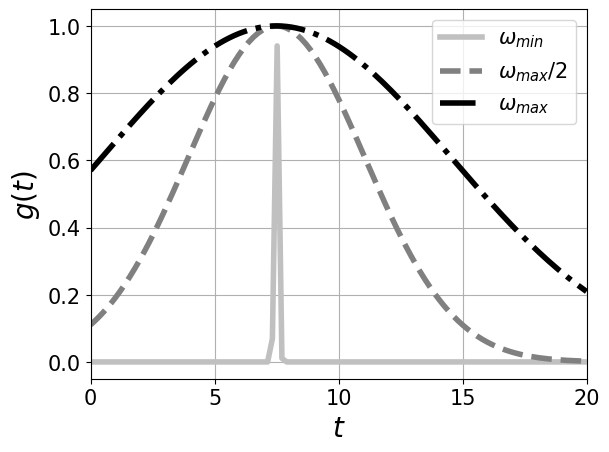

In [11]:
w_list, C_wt, D_wt, const, t = load_coerece('gauss2')

lw_list = ['-', '--', '-.']
c_list = ['silver', 'gray','black']
indices = [1, len(w_list)//2, -1]

w_label = ['$\omega_{min}$','$\omega_{max}$/2','$\omega_{max}$']
# NÃO ESTÁ FINALIZADO
for i, idx in enumerate(indices):
    g = np.exp(-(t-7.5)**2/w_list[idx]**2)
    plt.plot(t, g, lw=4, ls=lw_list[i], color=c_list[i], label=w_label[i])


plt.legend(fontsize=15)
plt.ylabel('$g(t)$', fontsize=20)
plt.xlabel('$t$', fontsize=20)
#plt.yscale('log')
plt.yticks(fontsize=15)
plt.xticks([0, 5, 10, 15, 20], fontsize=15)
plt.xlim(0, 20)
plt.grid(True)
plt.show()

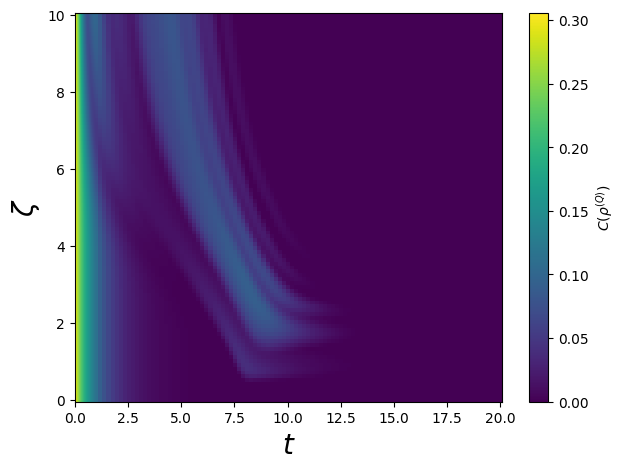

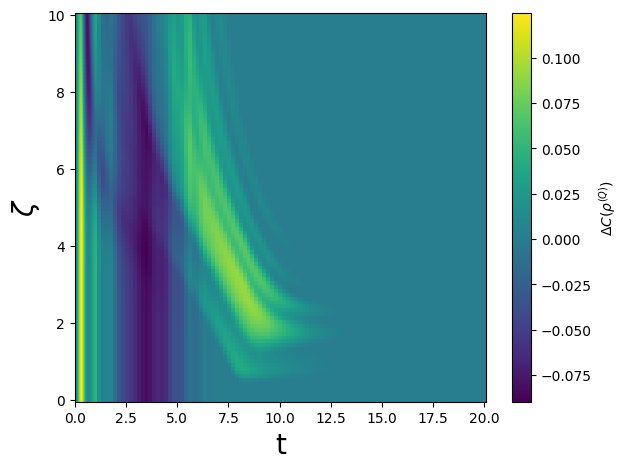

In [12]:
w_list, C_wt, D_wt, const, t = load_coerece('gauss2')

plot_coherence_and_difference(
    t=t,
    list=w_list,
    C_wt=C_wt,
    D_wt=D_wt,
    experiment='gauss2'
)

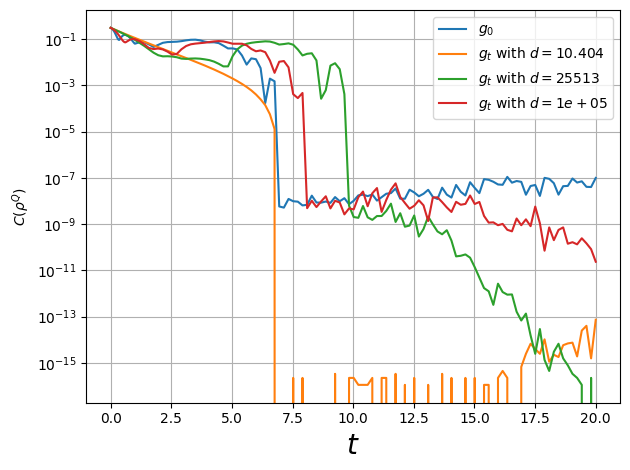

In [13]:
plot_selected_coherences(
    t=t,
    const=const,
    C_wt=C_wt,
    list=w_list,
    indices=indices,
)


### 3.1.2 - $T_{max}$ pequeno
$T=25$

$T_{max}=50$

<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
/var/folders/ds/vr9pfb552rqfjz20kskk9g7m0000gn/T/ipykernel_2825/2582898821.py:7: S

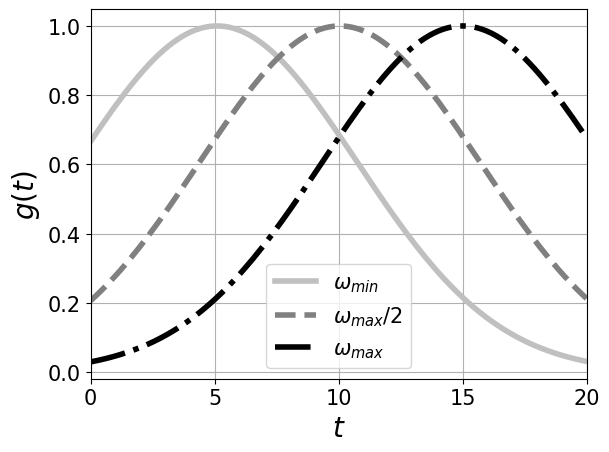

In [17]:
w_list, C_wt, D_wt, const, t = load_coerece('gauss1')

lw_list = ['-', '--', '-.']
c_list = ['silver', 'gray','black']
indices = [1, len(w_list)//2, -1]

w_label = ['$\omega_{min}$','$\omega_{max}$/2','$\omega_{max}$']
# NÃO ESTÁ FINALIZADO
for i, idx in enumerate(indices):
    g = np.exp(-(t-w_list[idx])**2/8**2)
    plt.plot(t, g, lw=4, ls=lw_list[i], color=c_list[i], label=w_label[i])


plt.legend(fontsize=15)
plt.ylabel('$g(t)$', fontsize=20)
plt.xlabel('$t$', fontsize=20)
#plt.yscale('log')
plt.yticks(fontsize=15)
plt.xticks([0, 5, 10, 15, 20], fontsize=15)
plt.xlim(0, 20)
plt.grid(True)
plt.show()

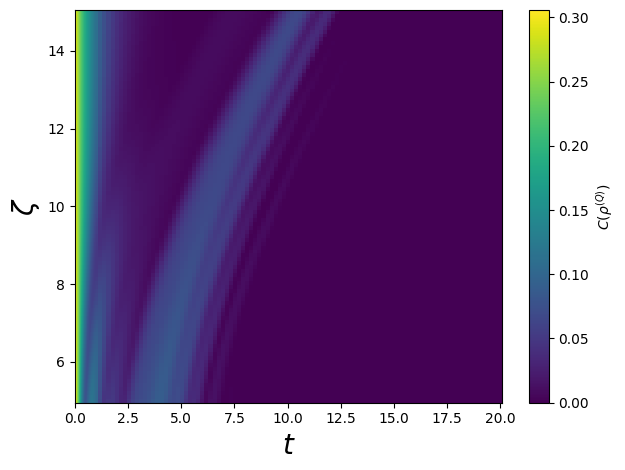

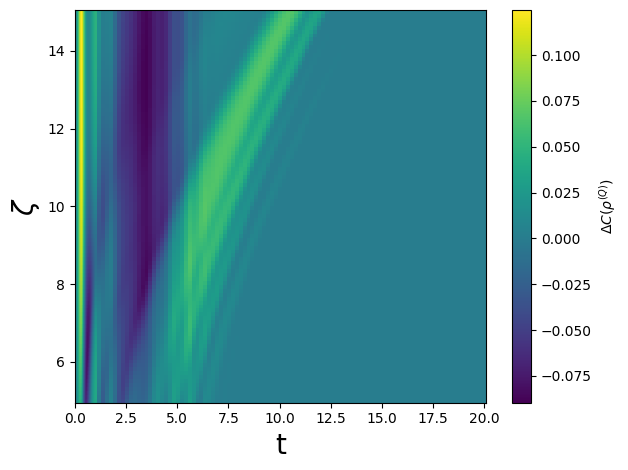

In [18]:
w_list, C_wt, D_wt, const, t = load_coerece('gauss1')

plot_coherence_and_difference(
    t=t,
    list=w_list,
    C_wt=C_wt,
    D_wt=D_wt,
    experiment='gauss1'
)

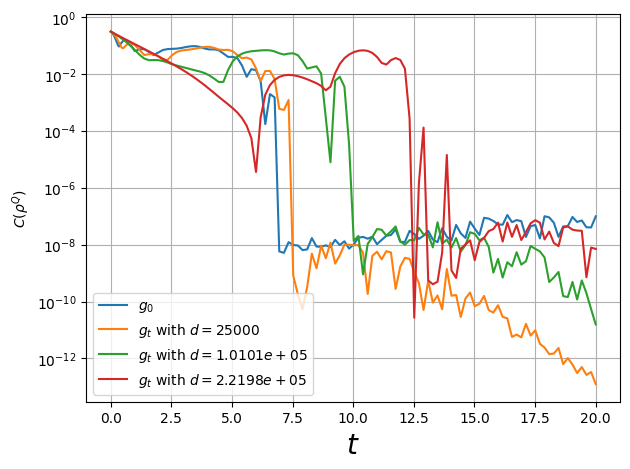

In [19]:
# Aqui não sei como ver essa variação, então só vou plotar primeiro, meio e ultimo. ignore o d no gráfico
indices = [0, len(w_list)//2, -2]

plot_selected_coherences(
    t=t,
    const=const,
    C_wt=C_wt,
    list=w_list,
    indices=indices,
)


# 4. Trigonométricas

Vamos considerar a modulação do tipo,

\begin{equation}
    g(t) = g_0 \cos(\omega t + \phi),
\end{equation}
mas modificando os tais parâmetros para compreender diferentes cenários físicos.

## 4.1 Cosseno
Aqui, vamos verifical tal comportamento fazendo $\phi=0$, $0 < \omega< 2\pi/50$ e $0<t<50$.

<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
/var/folders/ds/vr9pfb552rqfjz20kskk9g7m0000gn/T/ipykernel_2825/429891755.py:7: Sy

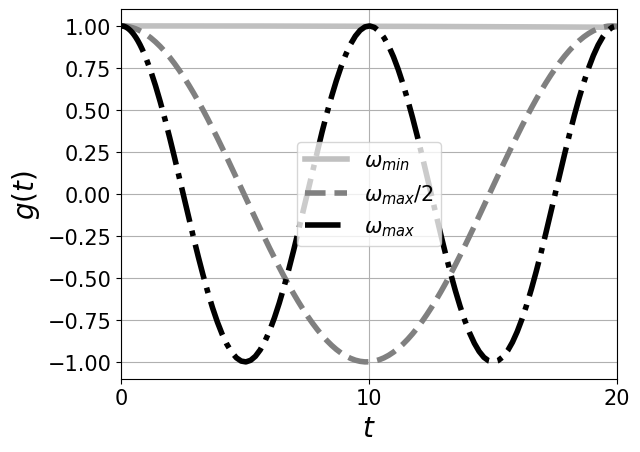

In [21]:
w_list, C_wt, D_wt, const, t = load_coerece('cos1')

lw_list = ['-', '--', '-.']
c_list = ['silver', 'gray','black']
indices = [1, len(w_list)//2, -1]

w_label = ['$\omega_{min}$','$\omega_{max}$/2','$\omega_{max}$']
# NÃO ESTÁ FINALIZADO
for i, idx in enumerate(indices):
    g = np.cos(w_list[idx]*t)
    plt.plot(t, g, lw=4, ls=lw_list[i], color=c_list[i], label=w_label[i])


plt.legend(fontsize=15)
plt.ylabel('$g(t)$', fontsize=20)
plt.xlabel('$t$', fontsize=20)
#plt.yscale('log')
plt.yticks(fontsize=15)
plt.xticks([0, 10, 20], fontsize=15)
plt.xlim(0, 20)
plt.grid(True)
plt.show()

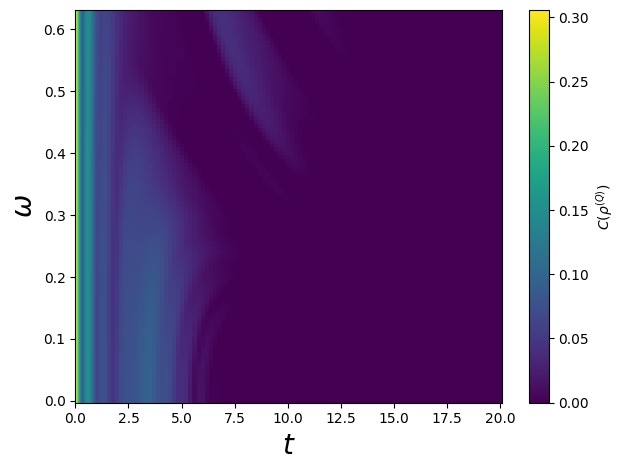

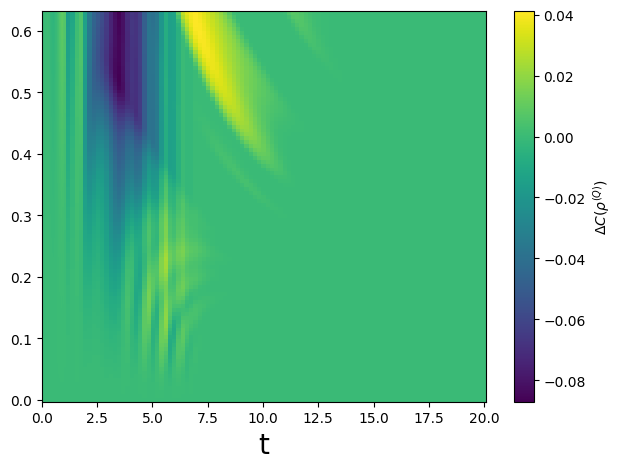

In [22]:
w_list, C_wt, D_wt, const, t = load_coerece('cos1')

plot_coherence_and_difference(
    t=t,
    list=w_list,
    C_wt=C_wt,
    D_wt=D_wt,
    experiment='cos1'
)

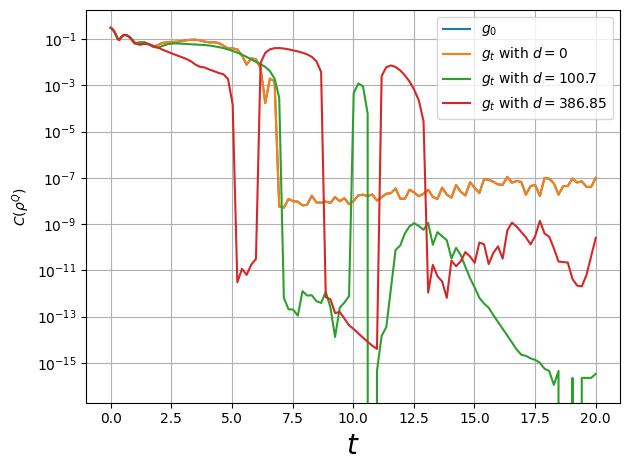

In [23]:
# Aqui não sei como ver essa variação, então só vou plotar primeiro, meio e ultimo. ignore o d no gráfico
indices = [0, len(w_list)//2, -2]

plot_selected_coherences(
    t=t,
    const=const,
    C_wt=C_wt,
    list=w_list,
    indices=indices,
)
